In [254]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# brute force calculation of every single ion coupling to every single mode -- radial only

In [ ]:
N = np.arange(3,4)
P_opt = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
mode1_list = result["mode_lists"][1]
mode2_list = result["mode_lists"][2]

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([0.58037073, 0.57660705, 0.5750601 ])), (1, array([0.57661239, 0.57882321, 0.57661239])), (2, array([0.5750601 , 0.57660705, 0.58037073]))]
[(0, (0, 2, 1), 0.5803707288390433)]
[(1, (2, 0, 1), 0.5766123878550536)]
[(2, (2, 0, 1), 0.5803707288390464)]
[(0, (0, 2, 1), 0.5803707288390433), (2, (2, 0, 1), 0.5803707288390464)]


In [256]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [(tweezed_ion, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove any unusable group keys (nan, None, empty tuple)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 3. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by stringified key
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

    # Compute and append best coupling info
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # find which ion → mode gives the minimum absolute value
        # (the one responsible for score)
        best_ion_index = min(range(len(mapping)), key=lambda i: abs(mapping[i]))
        best_mode_index = mapping[best_ion_index]

        # new 4-tuple
        augmented.append(
            (tweezed_ion, mapping, score, (best_ion_index, best_mode_index))
        )

    return augmented




import numpy as np
import math

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




DO NOT NAME ANYTHING ELSE RESULTS OR UNTWEEZED RESULTS OR TRY TO RUN THE CODE BLOCK UNDERNEATH THIS AGAIN. BOTH OF THEM TAKE LIKE 20 MINUTES

In [257]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))


/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:353: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals))/(2*pi*m) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)


In [258]:
P_opt = [1]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_high_P = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_high_P.append((Ni, winners))

/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:353: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals))/(2*pi*m) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)


In [259]:
untweezed_results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


Keys: [0, 1]
Keys: [0, 1, 2]
Keys: [0, 1, 2, 3]
Keys: [0, 1, 2, 3, 4]
Keys: [0, 1, 2, 3, 4, 5]
Keys: [0, 1, 2, 3, 4, 5, 6]


/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:353: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals))/(2*pi*m) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)


In [260]:
results[5-2]

(5,
 [(1, (1, 4, 0, 3, 2), 0.5600374898696806, (2, 0)),
  (3, (3, 0, 4, 1, 2), 0.5600374898700543, (1, 0))])

In [261]:
results_high_P[5-2]

(5,
 [(2, (2, 0, 4, 3, 1), -0.6291865426727158, (1, 0)),
  (2, (2, 4, 0, 3, 1), -0.6291865426727158, (2, 0))])

In [262]:
untweezed_results[5-2]

(5,
 [(None, (0, 4, 2, 1, 3), 0.44721359549996087),
  (None, (0, 4, 2, 3, 1), 0.44721359549996087)])

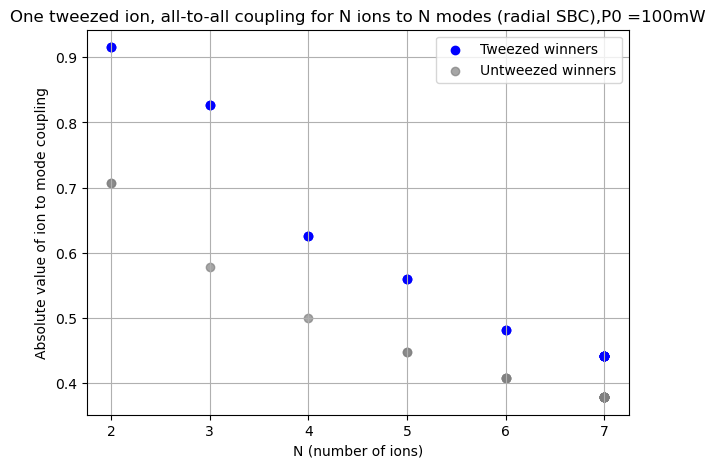

In [264]:
# ...existing code...
# --- Prepare data for plotting ---

# Tweezed winners (results)
x_tweezed = []
y_tweezed = []

for N_val, winners in results:
    if not winners:
        continue
    for win in winners:
        # win may be (tweezed_ion, mapping, val) or (tweezed_ion, mapping, val, coupling)
        if len(win) < 3:
            continue
        val = win[2]
        x_tweezed.append(N_val)
        y_tweezed.append(abs(val))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        if len(win) < 3:
            continue
        val = win[2]
        x_untweezed.append(N_val)
        y_untweezed.append(abs(val))

# Convert to arrays (optional)
x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)
x_untweezed = np.array(x_untweezed)
y_untweezed = np.array(y_untweezed)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC),P0 =100mW")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

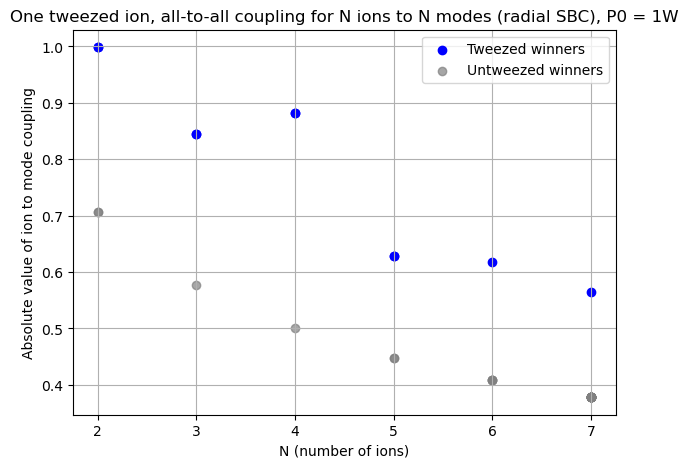

In [265]:
# ...existing code...
# --- Prepare data for plotting ---

# Tweezed winners (results_high_P)
x_tweezed = []
y_tweezed = []

for N_val, winners in results_high_P:
    if not winners:
        continue
    for win in winners:
        # support both (tweezed_ion, mapping, val) and (tweezed_ion, mapping, val, coupling)
        if not isinstance(win, (list, tuple)) or len(win) < 3:
            continue
        val = win[2]
        x_tweezed.append(N_val)
        y_tweezed.append(abs(val))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        if not isinstance(win, (list, tuple)) or len(win) < 3:
            continue
        val = win[2]
        x_untweezed.append(N_val)
        y_untweezed.append(abs(val))

# Convert to arrays (safe even if empty)
x_tweezed = np.asarray(x_tweezed)
y_tweezed = np.asarray(y_tweezed)
x_untweezed = np.asarray(x_untweezed)
y_untweezed = np.asarray(y_untweezed)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC), P0 = 1W")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

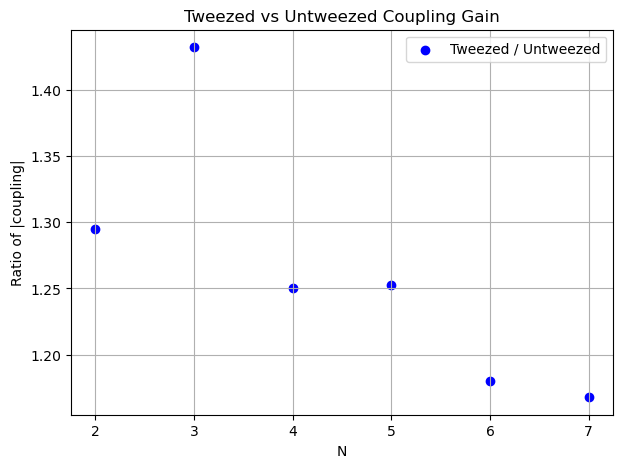

In [ ]:
# Best tweezed only
x = []
y = []
for N_val, winners in results:
    if winners:
        # Pick the winner with maximum abs(value)
        best = max(winners, key=lambda t: abs(t[2]))
        x.append(N_val)
        y.append(abs(best[2]))

# Best untweezed only
x_untweezed = []
y_untweezed = []
for N_val, winners in untweezed_results:
    if winners:
        best = max(winners, key=lambda t: abs(t[2]))
        x_untweezed.append(N_val)
        y_untweezed.append(abs(best[2]))

# Convert to arrays
x = np.array(x)
y = np.array(y)
x_untweezed = np.array(x_untweezed)
y_untweezed = np.array(y_untweezed)

# Compute ratio (make sure shapes match)
# If N values differ, you may need interpolation or alignment
ratio = y / y_untweezed

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, ratio, color='blue', label='Tweezed / Untweezed')
plt.xlabel("N")
plt.ylabel("Ratio of |coupling|")
plt.title("Tweezed vs Untweezed Coupling Gain")
plt.grid(True)
plt.legend()
plt.show()

## Showing the optimal configuration for N = 5


In [ ]:
print(results[5-2])
print(untweezed_results[5-2])

(5, [(1, (1, 4, 0, 3, 2), 0.5600374898696806, (2, 0)), (3, (3, 0, 4, 1, 2), 0.5600374898700543, (1, 0))])
(5, [(None, (0, 4, 2, 1, 3), 0.44721359549996087), (None, (0, 4, 2, 3, 1), 0.44721359549996087)])


In [ ]:
N = 5
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (1, 4, 0, 3, 2)
tweezed_ions = 1
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N5 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N5)




[(1307259.3382369007, array([-0.16112589, -0.96793728, -0.18191348, -0.05977305, -0.02169192])), (965257.9042682298, array([-0.02535758, -0.09921646,  0.27893373,  0.54044748,  0.787163  ])), (896702.7614526568, array([-0.98601837,  0.15544653,  0.04724132,  0.00989057, -0.03570127])), (823617.494653064, array([-0.0334424 ,  0.13459584, -0.57926837, -0.54172158,  0.59308638])), (601715.8646941261, array([ 0.0066946 , -0.10475616,  0.74250918, -0.64092403,  0.16394463]))]


In [ ]:
def sweep_P0_tweezed_snippet(
    P0_list,
    N,
    indices,
    tweezed_ions,
    f_rf_r,
    mode_calc_r,
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    w0=1e-6,
):
    """
    Run the exact snippet over a list of P0 values.
    Returns a list of tuples: (P0, min_selected)
    """
    import numpy as np

    tweezed_idx = np.atleast_1d(tweezed_ions).astype(int)

    results = []

    w_rf_a = f_rf_r / 3 * 2 * np.pi
    ueq = ion_spacing(N, w_rf_a)[0]

    for P0 in P0_list:
        U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
        w_tw_r = omega_tweezer_r(U, w0, m)

        # combine radial frequencies
        w_rf_r = f_rf_r * 2 * np.pi
        w_rf_combined = np.full((int(N),), w_rf_r, dtype=float)
        w_rf_combined[tweezed_idx] = np.sqrt(w_tw_r**2 + w_rf_r**2)

        data_N = mode_calc_r(m, w_rf_combined, ueq, N)

        try:
            selected = [arr[i] for (_, arr), i in zip(data_N, indices)]
            min_selected = None if (selected is None or len(selected) == 0) else min(selected)
        except Exception:
            min_selected = None

        # save as tuple (P0, min_selected)
        results.append((P0, min_selected))

    return results


In [ ]:
P_list = np.linspace(0.1, 20, 200)
N = 5
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N5_power_sweep = run_optimal_mode_selection_tweezed_power_sweep(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

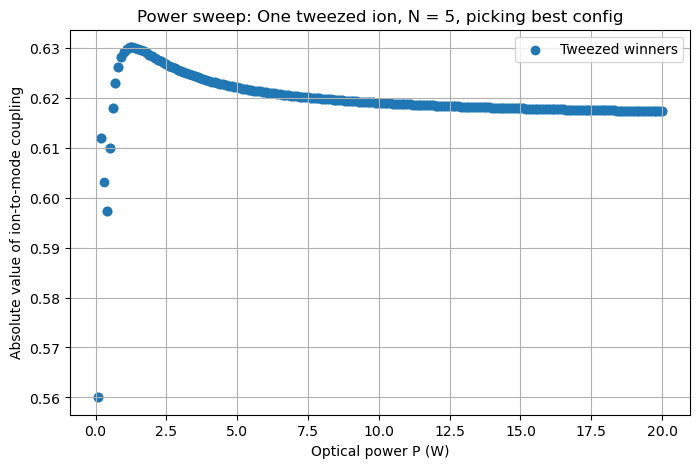

In [ ]:

x_tweezed = []
y_tweezed = []

for P, winners in N5_power_sweep:
    if not winners:
        continue
    for tweezed_ion, mapping, val, coupling in winners:
        x_tweezed.append(P)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
N5_power_sweep

[(0.1,
  [(1, (1, 4, 0, 3, 2), 0.5600374898696806, (2, 0)),
   (3, (3, 0, 4, 1, 2), 0.5600374898700543, (1, 0))]),
 (0.3020408163265306, [(1, (1, 4, 0, 3, 2), -0.6028223436622399, (2, 0))]),
 (0.5040816326530613,
  [(2, (2, 0, 4, 3, 1), -0.6102602560872954, (1, 0)),
   (2, (2, 4, 0, 3, 1), -0.6102602560872954, (2, 0))]),
 (0.7061224489795919,
  [(2, (2, 0, 4, 3, 1), -0.6231995711835343, (1, 0)),
   (2, (2, 4, 0, 3, 1), -0.6231995711835343, (2, 0))]),
 (0.9081632653061225,
  [(2, (2, 0, 4, 3, 1), -0.6281730262740861, (1, 0)),
   (2, (2, 4, 0, 3, 1), -0.6281730262740861, (2, 0))]),
 (1.1102040816326533,
  [(2, (2, 0, 4, 3, 1), -0.6298373904499567, (1, 0)),
   (2, (2, 4, 0, 3, 1), -0.6298373904499567, (2, 0))]),
 (1.3122448979591839,
  [(2, (2, 0, 4, 3, 1), -0.630104093108158, (1, 0)),
   (2, (2, 4, 0, 3, 1), -0.630104093108158, (2, 0))]),
 (1.5142857142857145,
  [(2, (2, 0, 4, 3, 1), 0.629775410278256, (1, 0)),
   (2, (2, 4, 0, 3, 1), 0.629775410278256, (2, 0))]),
 (1.716326530612245,
  

In [ ]:
N = 5
f_rf_r = 1e6
f_rf_a = f_rf_r/3
w0=1e-6
P_opt = 0.211
N5= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)

In [ ]:
N5.iloc[2]

N                                                                                                                                      5
Tweezed ions                                                                                                                        (1,)
P_tweezer (W)                                                                                                                      0.211
Combined radial frequencies              [6283185.307179586, 6926298.794640903, 6283185.307179586, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                1034439.844241
Mode0_eigvec                      [0.4490408020302797, 0.6850220359832377, 0.41723596165501053, 0.3107053845836492, 0.24183358869670754]
Mode1_freq                                                                                                                 952631.755053
Mode1_eigvec                     [-0.3941

In [ ]:
N5.iloc[4]

N                                                                                                                                       5
Tweezed ions                                                                                                                         (3,)
P_tweezer (W)                                                                                                                       0.211
Combined radial frequencies               [6283185.307179586, 6283185.307179586, 6283185.307179586, 6926298.794640903, 6283185.307179586]
Mode0_freq                                                                                                                 1034439.844241
Mode0_eigvec                      [0.24183358869774477, 0.31070538458348546, 0.41723596165545845, 0.6850220359844205, 0.4490408020276137]
Mode1_freq                                                                                                                  952631.755053
Mode1_eigvec                    [-

## Showing the optimal configuration for N=6

In [ ]:
print(results[6-2])
print(untweezed_results[6-2])

(6, [(4, (4, 0, 5, 1, 3, 2), -0.48169683068714303, (1, 0)), (4, (4, 5, 0, 1, 3, 2), -0.48169683068714303, (2, 0))])
(6, [(None, (3, 0, 5, 1, 4, 2), 0.40824829046386346), (None, (3, 0, 5, 4, 1, 2), 0.40824829046386346), (None, (3, 5, 0, 1, 4, 2), 0.40824829046386346), (None, (3, 5, 0, 4, 1, 2), 0.40824829046386346)])


In [ ]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (4,0,5,1,3,2)
tweezed_ions = 4
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1285833.6338140836, array([-0.01552816, -0.03520725, -0.08064535, -0.21269358, -0.95408157,
       -0.19106402])), (969298.1673031122, array([ 0.70735831,  0.54770888,  0.38634838,  0.19704475, -0.10079272,
       -0.0375276 ])), (874494.9192434419, array([ 0.10404677, -0.01009732, -0.07272747, -0.10305192, -0.1669061 ,
        0.97226832])), (836898.4643219957, array([-0.64123068,  0.2699328 ,  0.55214643,  0.40990764, -0.16323972,
        0.12814966])), (630021.9325592205, array([ 0.2712399 , -0.70770363,  0.15827419,  0.61843935, -0.13318085,
        0.01814931])), (259488.67011631007, array([ 0.06188291, -0.35350435,  0.71346028, -0.59567073,  0.08559906,
       -0.00536684]))]


In [ ]:
P_list = np.linspace(0.1, 20, 200)
N = 6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N6_power_sweep = run_optimal_mode_selection_tweezed_power_sweep(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)


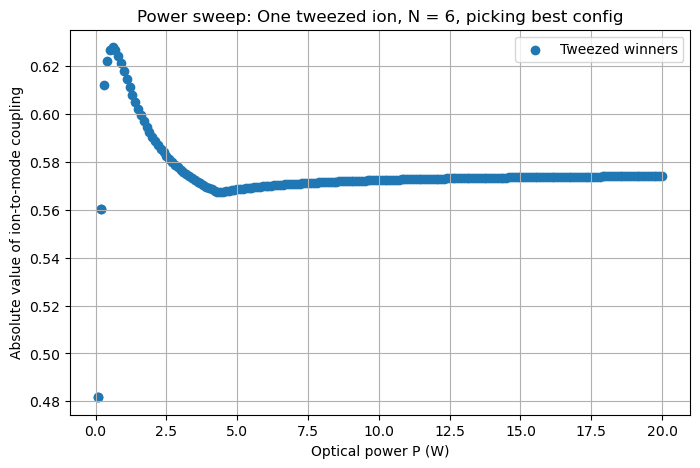

In [ ]:
x_tweezed = []
y_tweezed = []

for P, winners in N6_power_sweep:
    if not winners:
        continue
    for tweezed_ion, mapping, val, coupling in winners:
        x_tweezed.append(P)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
N6_power_sweep

[(0.1,
  [(4, (4, 0, 5, 1, 3, 2), -0.48169683068714303, (1, 0)),
   (4, (4, 5, 0, 1, 3, 2), -0.48169683068714303, (2, 0))]),
 (0.42222222222222217, [(2, (2, 5, 0, 4, 1, 3), 0.623526525508299, (2, 0))]),
 (0.7444444444444444, [(2, (2, 5, 0, 4, 1, 3), 0.6258741782557342, (2, 0))]),
 (1.0666666666666667, [(2, (2, 5, 0, 4, 1, 3), -0.6156495029352013, (2, 0))]),
 (1.3888888888888888, [(2, (2, 5, 0, 4, 1, 3), 0.6052568379608133, (2, 0))]),
 (1.711111111111111, [(2, (2, 5, 0, 4, 1, 3), -0.5967461026622846, (2, 0))]),
 (2.033333333333333, [(2, (2, 5, 0, 4, 1, 3), -0.5900129456994778, (2, 0))]),
 (2.3555555555555556, [(2, (2, 5, 0, 4, 1, 3), -0.5846619905327044, (2, 0))]),
 (2.6777777777777776, [(2, (2, 5, 0, 4, 1, 3), -0.5803483700767712, (2, 0))]),
 (3.0, [(2, (2, 5, 0, 4, 1, 3), -0.5768150955493386, (2, 0))])]

In [ ]:
N = 6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
w0=1e-6
P_opt = 0.211
N6= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
N6.iloc[2]
N6.iloc[4]


N                                                                                                                                                             6
Tweezed ions                                                                                                                                               (3,)
P_tweezer (W)                                                                                                                                             0.211
Combined radial frequencies                  [6283185.307179586, 6283185.307179586, 6283185.307179586, 6926298.794640903, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                                       1025306.946855
Mode0_eigvec                         [0.2885694807915973, 0.3414467461015234, 0.4142934995902454, 0.5693495503543256, 0.42520406633312546, 0.35149005962433644]
Mode1_freq                              

# Brute force calculation of 1 ion 1 tweezer for midcurcuit meas type of a setup

In [287]:
N = np.arange(2,3)
P_opt = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
mode1_list = result["mode_lists"][1]

print(mode0_list)
print(mode1_list)

[(nan, array([0.70710678, 0.70710678])), (0, array([0.71034434, 0.70385433])), (1, array([0.70385433, 0.71034434]))]
[(nan, array([-0.70710678,  0.70710678])), (0, array([-0.70385433,  0.71034434])), (1, array([-0.71034434,  0.70385433]))]


In [328]:
import math
import pandas as pd
from collections import defaultdict

def summarized_dataframe(*lists_of_pairs):
    """
    Summarizes lists of (key, array) pairs into a DataFrame where each row is:
        key, array index, list of all values for that index across lists
    """
    # key -> index -> list of values
    grouped = defaultdict(lambda: defaultdict(list))

    for L in lists_of_pairs:
        for key, arr in L:
            # Normalize nan keys
            if isinstance(key, float) and math.isnan(key):
                key_str = 'nan'
            else:
                key_str = key

            for i, val in enumerate(arr):
                grouped[key_str][i].append(val)

    # Build DataFrame rows
    rows = []
    for key in grouped:
        for idx in sorted(grouped[key]):
            rows.append({
                'key': key,
                'index': idx,
                'values': grouped[key][idx]
            })

    df = pd.DataFrame(rows)
    return df



In [329]:
middle = summarized_dataframe(*[mode0_list, mode1_list])

In [330]:
middle

,key,index,values
0,nan,0,"[0.7071067811865476, -0.7071067811865476]"
1,nan,1,"[0.7071067811865476, 0.7071067811865476]"
2,0,0,"[0.7103443381015643, -0.7038543324630819]"
3,0,1,"[0.7038543324630819, 0.7103443381015643]"
4,1,0,"[0.7038543324630819, -0.7103443381015643]"
5,1,1,"[0.7103443381015643, 0.7038543324630819]"


In [318]:
(0.71034434**2 + (-0.70385433)**2)

0.9999999992297846

In [313]:
middle[0][0][0]

0.7103443381015643

In [317]:
middle[0][0][1]**2

0.49541092132705067